In [1]:
import jax
import jax.numpy as jnp
import jax.image
import tensorflow_datasets as tfds
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
import os


2025-03-15 01:31:03.401228: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742016663.414726 1371574 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742016663.418694 1371574 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def load_and_preprocess_mnist(labels=None, resolution=(8, 8)):
    """Load and preprocess MNIST dataset for specified labels and resolution.
    
    Args:
        labels: List/tuple of integer labels to include, or None for all labels
        resolution: Tuple of (height, width) for output image size
        
    Returns:
        Tuple of (images_array, labels_array) as JAX arrays
    """
    # Build and prepare the MNIST dataset using tensorflow_datasets
    ds_builder = tfds.builder("mnist")
    ds_builder.download_and_prepare()
    
    # Load the training split as supervised (image, label) pairs
    ds = ds_builder.as_dataset(split="train", as_supervised=True)
    
    # Filter for specific labels if provided
    if labels is not None:
        if not isinstance(labels, (list, tuple)):
            labels = [labels]  # Convert single label to list
        ds = ds.filter(lambda _, label: tf.reduce_any([tf.equal(label, l) for l in labels]))
    images_list = []
    labels_list = []
    
    # Iterate over the dataset. Each image is originally 28x28x1
    for image, label in tfds.as_numpy(ds):
        # Normalize image to [0, 1]
        image = image.astype(np.float32) / 255.0
        
        # Convert to a JAX array
        image_jax = jnp.array(image)
        
        # Resize to target resolution. Preserve the channel dimension
        resized = jax.image.resize(image_jax, shape=(*resolution, image_jax.shape[-1]), method='linear')
        
        images_list.append(resized)
        labels_list.append(label)
    
    # Stack the images and labels into arrays
    images_array = jnp.stack(images_list)
    labels_array = jnp.array(labels_list)
    
    return images_array, labels_array

W0000 00:00:1742016666.065159 1371574 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


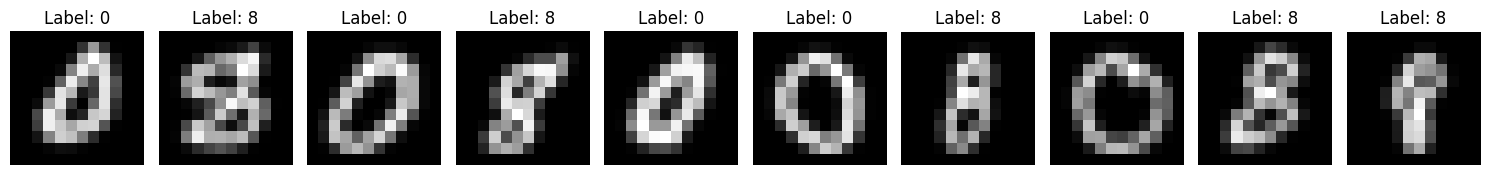

In [3]:
labels = [0,8]
resolution = (12,12)
images, labels_array = load_and_preprocess_mnist(labels=labels, resolution=resolution)

# Plot a few examples
num_examples = 10  # number of examples to display
fig, axes = plt.subplots(1, num_examples, figsize=(15, 2))

for i in range(num_examples):
    # Remove channel dimension if it exists (i.e., converting 8x8x1 to 8x8)
    img = images[i]
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    
    axes[i].imshow(np.array(img), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Label: {labels_array[i]}")

plt.tight_layout()
plt.show()

In [ ]:
specifics = f"labels_{labels}_resolution_{resolution}"

# Create the target directory if it doesn't exist.
save_folder = f"data/MNIST/"
os.makedirs(save_folder, exist_ok=True)

# Save the flattened jnp.array as a .npy file.
save_path = os.path.join(save_folder, f"mnist_{specifics}.npy")
np.save(save_path, np.array(images.reshape(images.shape[0], -1) ))  # Convert to numpy array for saving

print("Saved preprocessed data to:", save_path)

Saved preprocessed data to: data/MNIST/mnist_labels_[0, 8]_resolution_(12, 12).npy
